### EXAMPLE MD ANALYSIS

**Import libraries**

In [1]:
from matplotlib import pyplot as plt
import numpy as np

In [2]:
import MDAnalysis as mda
print("Using MDAnalysis version", mda.__version__)

Using MDAnalysis version 2.10.0


## Import single structure

In [3]:
u=mda.Universe('adk.psf','adk.pdb')

/home/jordi/.conda/envs/generalmd/lib/python3.14/site-packages/MDAnalysis/coordinates/PDB.py:479: UserWarning: 1 A^3 CRYST1 record, this is usually a placeholder. Unit cell dimensions will be set to None.
  warnings.warn(


### Exemples analisi estructura

In [4]:
print(u.residues)

<ResidueGroup [<Residue MET, 1>, <Residue ARG, 2>, <Residue ILE, 3>, ..., <Residue ILE, 212>, <Residue LEU, 213>, <Residue GLY, 214>]>


In [5]:
u.atoms

<AtomGroup with 3341 atoms>

In [6]:
last_five = u.atoms[-5:]
print(last_five)

<AtomGroup [<Atom 3337: HA1 of type 6 of resname GLY, resid 214 and segid 4AKE>, <Atom 3338: HA2 of type 6 of resname GLY, resid 214 and segid 4AKE>, <Atom 3339: C of type 32 of resname GLY, resid 214 and segid 4AKE>, <Atom 3340: OT1 of type 72 of resname GLY, resid 214 and segid 4AKE>, <Atom 3341: OT2 of type 72 of resname GLY, resid 214 and segid 4AKE>]>


In [7]:
print(u.select_atoms('resname ASP or resname GLU'))

<AtomGroup [<Atom 318: N of type 54 of resname GLU, resid 22 and segid 4AKE>, <Atom 319: HN of type 1 of resname GLU, resid 22 and segid 4AKE>, <Atom 320: CA of type 22 of resname GLU, resid 22 and segid 4AKE>, ..., <Atom 3271: OE2 of type 72 of resname GLU, resid 210 and segid 4AKE>, <Atom 3272: C of type 20 of resname GLU, resid 210 and segid 4AKE>, <Atom 3273: O of type 70 of resname GLU, resid 210 and segid 4AKE>]>


In [8]:
print(u.atoms[:20].names)

['N' 'HT1' 'HT2' 'HT3' 'CA' 'HA' 'CB' 'HB1' 'HB2' 'CG' 'HG1' 'HG2' 'SD'
 'CE' 'HE1' 'HE2' 'HE3' 'C' 'O' 'N']


In [9]:
print(u.atoms[:20].charges)

[-0.30000001  0.33000001  0.33000001  0.33000001  0.20999999  0.1
 -0.18000001  0.09        0.09       -0.14        0.09        0.09
 -0.09       -0.22        0.09        0.09        0.09        0.50999999
 -0.50999999 -0.47      ]


In [10]:
print(u.atoms[0:20].positions)

[[ 11.736   8.501 -10.445]
 [ 12.365   7.84  -10.835]
 [ 12.092   9.442 -10.725]
 [ 10.832   8.309 -10.964]
 [ 11.665   8.393  -8.983]
 [ 12.673   8.56   -8.681]
 [ 10.74    9.57   -8.591]
 [  9.639   9.27   -8.968]
 [ 11.095  10.519  -9.142]
 [ 10.557   9.934  -7.112]
 [ 11.449  10.323  -6.693]
 [ 10.277   8.979  -6.597]
 [  9.25   11.105  -6.91 ]
 [ 10.444  12.492  -7.162]
 [ 11.472  12.294  -7.661]
 [ 10.565  13.068  -6.252]
 [  9.883  13.172  -7.79 ]
 [ 11.167   7.129  -8.375]
 [ 10.151   6.649  -8.755]
 [ 11.841   6.642  -7.275]]


In [11]:
ca = u.select_atoms('resid 1-5 and name CA')
print(ca.positions)

[[11.665  8.393 -8.983]
 [11.415  5.434 -6.513]
 [ 8.96   5.613 -3.613]
 [ 8.29   3.076 -0.797]
 [ 5.011  3.764  1.13 ]]


In [12]:
print(ca.center_of_mass())

[ 9.06820002  5.2559999  -3.75519994]


In [13]:
nhh = u.atoms[:3]
print(nhh.names)

['N' 'HT1' 'HT2']


In [14]:
angle_nhh = nhh.angle
print(f"N-H-H angle: {angle_nhh.value():.2f}")

N-H-H angle: 38.01


In [15]:
hnh = u.atoms[[1, 0, 2]]
print(hnh.names)

['HT1' 'N' 'HT2']


In [16]:
angle_hnh = hnh.angle
print(f"N-H-H angle: {angle_hnh.value():.2f}")

N-H-H angle: 106.19


## Working with trajectories

### Import trajectory

In [17]:
u=mda.Universe('adk.psf','unfolding.dcd')

/home/jordi/.conda/envs/generalmd/lib/python3.14/site-packages/MDAnalysis/coordinates/DCD.py:171: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


veure detalls del que hem importat

In [18]:
print(u)

<Universe with 3341 atoms>


In [19]:
u.trajectory

<DCDReader unfolding.dcd with 98 frames of 3341 atoms>

In [21]:
print(u.trajectory)

<DCDReader unfolding.dcd with 98 frames of 3341 atoms>


In [22]:
print(len(u.trajectory))

98


In [23]:
for ts in u.trajectory:
    time = u.trajectory.time
    print(f"Frame: {ts.frame:3d}, Time: {time:4.0f} ps")

Frame:   0, Time:    0 ps
Frame:   1, Time:    1 ps
Frame:   2, Time:    2 ps
Frame:   3, Time:    3 ps
Frame:   4, Time:    4 ps
Frame:   5, Time:    5 ps
Frame:   6, Time:    6 ps
Frame:   7, Time:    7 ps
Frame:   8, Time:    8 ps
Frame:   9, Time:    9 ps
Frame:  10, Time:   10 ps
Frame:  11, Time:   11 ps
Frame:  12, Time:   12 ps
Frame:  13, Time:   13 ps
Frame:  14, Time:   14 ps
Frame:  15, Time:   15 ps
Frame:  16, Time:   16 ps
Frame:  17, Time:   17 ps
Frame:  18, Time:   18 ps
Frame:  19, Time:   19 ps
Frame:  20, Time:   20 ps
Frame:  21, Time:   21 ps
Frame:  22, Time:   22 ps
Frame:  23, Time:   23 ps
Frame:  24, Time:   24 ps
Frame:  25, Time:   25 ps
Frame:  26, Time:   26 ps
Frame:  27, Time:   27 ps
Frame:  28, Time:   28 ps
Frame:  29, Time:   29 ps
Frame:  30, Time:   30 ps
Frame:  31, Time:   31 ps
Frame:  32, Time:   32 ps
Frame:  33, Time:   33 ps
Frame:  34, Time:   34 ps
Frame:  35, Time:   35 ps
Frame:  36, Time:   36 ps
Frame:  37, Time:   37 ps
Frame:  38, 

In [24]:
for ts in u.trajectory:
    time = u.trajectory.time
    rgyr = u.atoms.radius_of_gyration()
    print(f"Frame: {ts.frame:3d}, Time: {time:4.0f} ps, Rgyr: {rgyr:.4f} A")

Frame:   0, Time:    0 ps, Rgyr: 16.6690 A
Frame:   1, Time:    1 ps, Rgyr: 16.6732 A
Frame:   2, Time:    2 ps, Rgyr: 16.7315 A
Frame:   3, Time:    3 ps, Rgyr: 16.7223 A
Frame:   4, Time:    4 ps, Rgyr: 16.7440 A
Frame:   5, Time:    5 ps, Rgyr: 16.7185 A
Frame:   6, Time:    6 ps, Rgyr: 16.7741 A
Frame:   7, Time:    7 ps, Rgyr: 16.7764 A
Frame:   8, Time:    8 ps, Rgyr: 16.7894 A
Frame:   9, Time:    9 ps, Rgyr: 16.8289 A
Frame:  10, Time:   10 ps, Rgyr: 16.8521 A
Frame:  11, Time:   11 ps, Rgyr: 16.8549 A
Frame:  12, Time:   12 ps, Rgyr: 16.8723 A
Frame:  13, Time:   13 ps, Rgyr: 16.9108 A
Frame:  14, Time:   14 ps, Rgyr: 16.9494 A
Frame:  15, Time:   15 ps, Rgyr: 16.9810 A
Frame:  16, Time:   16 ps, Rgyr: 17.0033 A
Frame:  17, Time:   17 ps, Rgyr: 17.0196 A
Frame:  18, Time:   18 ps, Rgyr: 17.0784 A
Frame:  19, Time:   19 ps, Rgyr: 17.1265 A
Frame:  20, Time:   20 ps, Rgyr: 17.1491 A
Frame:  21, Time:   21 ps, Rgyr: 17.1759 A
Frame:  22, Time:   22 ps, Rgyr: 17.2168 A
Frame:  23,

In [25]:
rgyr = []
time = []
protein = u.select_atoms("protein")
for ts in u.trajectory:
    time.append(u.trajectory.time)
    rgyr.append(protein.radius_of_gyration())

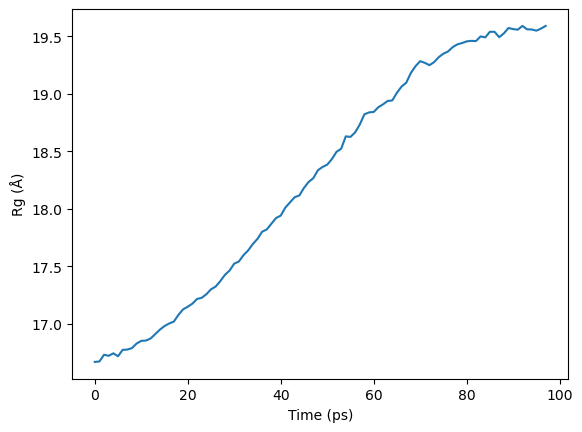

In [26]:
plt.plot(time,rgyr)
plt.xlabel('Time (ps)')
plt.ylabel('Rg (Å)')
plt.show()

**Save onto a data file**

In [27]:
fitxer=open('Rgir.dat','w')

In [28]:
for i in range(len(time)):
    fitxer.write(f'{round(time[i],0)} {round(rgyr[i],2)}\n')
fitxer.close()